In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_analysis=pd.read_csv('Data/data.csv')

In [47]:
#data cleaning and preprocessing

# Remove entries which do not have age, jersey number and nationality 

df_analysis = df_analysis[df_analysis['Nationality'].notna()]
df_analysis = df_analysis[df_analysis['Age'].notna()]
df_analysis = df_analysis[df_analysis['Jersey Number'].notna()]
# Fill missing values with 0 for numerical columns and mode for categorical columns 
df_analysis[['Goals per match', 'Headed goals', 'Goals with right foot', 'Goals with left foot','Penalties scored','Freekicks scored','Shots','Shots on target', 'Shooting accuracy %','Hit woodwork','Big chances missed','Clean sheets','Goals conceded','Tackles','Tackle success %','Offsides']] = df_analysis[['Goals per match', 'Headed goals', 'Goals with right foot', 'Goals with left foot', 'Penalties scored','Freekicks scored', 'Shots', 'Shots on target', 'Shooting accuracy %','Hit woodwork','Big chances missed','Clean sheets','Goals conceded','Tackles','Tackle success %','Offsides']].fillna(0)
df_analysis['Nationality']= df_analysis['Nationality'].fillna(df_analysis['Nationality'].mode()[0])
df_analysis['Age']= df_analysis['Age'].fillna(df_analysis['Age'].median())
# cleaning the percentage sign
df_analysis['Cross accuracy %'] = df_analysis['Cross accuracy %'].str.replace(r'%', '').astype(float)
df_analysis['Shooting accuracy %'] = df_analysis['Shooting accuracy %'].str.replace(r'%', '').astype(float)
df_analysis['Tackle success %'] = df_analysis['Tackle success %'].str.replace(r'%', '').astype(float)


print(df_analysis['Name'].duplicated().sum()) # check for duplicate entries(should be 0 )


# check if there are any invalid values in the percentage columns (values less than 0 or greater than 100)

for col in ['Shooting accuracy %','Tackle success %','Cross accuracy %']:
    if col in df_analysis.columns:
        invalid_values = df_analysis[(df_analysis[col] < 0) | (df_analysis[col] > 100)][col]
        print(f"{col} - number of invalid values: {len(invalid_values)}")
        if len(invalid_values) > 0:
            print(invalid_values)

0
Shooting accuracy % - number of invalid values: 0
Tackle success % - number of invalid values: 0
Cross accuracy % - number of invalid values: 0


In [48]:
# Now we can proceed with the analysis and visualization using the cleaned dataset (df_analysis)
#this function will be used to create radar charts for comparing players based on specified metrics. It takes the names of the two players, the list of metrics to compare, the dataframe containing the data, and the position of the players for labeling purposes.
def make_radar(name1, name2, metrics, df):
    num_vars = len(metrics)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()#generates a list of angles for each metric,endpoint=False ensures that the last angle does not overlap with the first one.
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))#subplot_kw=dict(polar=True) creates a polar subplot, which is necessary for a radar chart
    colors = ['#8E44AD', "#0F97F1"] #color of chart

    # Loop through the players and plot their radar charts
    for name, color in zip([name1, name2], colors):
        if name in df['Name'].values:
            values = df[df['Name'] == name][metrics].values.flatten().tolist()
            max_values = df[metrics].max().values
            values_norm = [values /max_values for values, max_values in zip(values, max_values)]
            values_norm += values_norm[:1]
            ax.plot(angles, values_norm, color=color, label=name)
            ax.fill(angles, values_norm, color=color, alpha=0.2)#fill the area under the radar chart with a color and set its transparency using alpha
        else:
            print(f"Player '{name}' not found in the dataframe.")    
    #It fixes the shape inside the radar chart 
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles[:-1]), labels=metrics)

    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))#bbox_to_anchor=(1.3, 1.1) places the legend outside the plot area to the right
    plt.title(f'General Comparison\n{name1} vs {name2}', fontsize=15)
    plt.savefig(f'{name1}_vs_{name2}_Radar_Chart.png')
    plt.show()


In [49]:
def the_top_player(df, column):
    top_value = df[column].max()
    players = df[df[column] == top_value]
    return list(zip(players['Name'], players[column]))

def the_bottom_player(df, column):
    bottom_value = df[column].min()
    players = df[df[column] == bottom_value]
    return list(zip(players['Name'], players[column]))

In [50]:
def analyze_best_players(data, metrics, title="Analysis"):
    print(f"\n=== {title} ===\n")

    for label, (column, mode) in metrics.items():
        if mode == "top":
            result = the_top_player(data, column)
        else:
            result = the_bottom_player(data, column)

        print(f"{label}: {result}")

In [51]:

#data cleaning for forwards
#filtering forwards with at least 1 appearance
forwards = df_analysis[df_analysis['Position'].str.contains('Forward')&(df_analysis['Appearances'] > 0)]
# Drop the specified columns from the forwards DataFrame
cols_to_drop = [
    'Clean sheets', 'Goals conceded', 'Tackles', 'Tackle success %', 
    'Last man tackles', 'Blocked shots', 'Interceptions', 'Clearances', 
    'Headed Clearance', 'Clearances off line', 'Own goals', 'Saves', 
    'Penalties saved', 'Punches', 'High Claims', 'Catches', 'Sweeper clearances', 'Throw outs', 'Goal Kicks','Through balls'	,'Accurate long balls'
]

forwards = forwards.drop(columns=cols_to_drop)

#feature engineering
 
forwards['shot_conversion'] = np.where(
    forwards['Shots'] > 0,
    forwards['Goals'] / forwards['Shots'],
    np.nan
)

forwards['shots_per_match'] =forwards['Shots'] / forwards['Appearances']

#goal per shot on target
forwards['goals_per_shot_on_target'] = np.where(
    forwards['Shots on target'] > 0,
    forwards['Goals'] / forwards['Shots on target'],
    np.nan
)
forwards['xG_estimated'] = (forwards['Shots on target'] * 0.3 +(forwards['Shots'] - forwards['Shots on target']) * 0.05 +forwards['Big chances missed'] * 0.4
)
forwards['xG_diff'] = forwards['Goals'] - forwards['xG_estimated']
bins = [15, 20, 25, 30, 35, 40]
labels = ['15-20', '21-25', '26-30', '31-35', '36-40']

forwards['Age Group'] = pd.cut(forwards['Age'], bins=[15, 20, 25, 30, 35], labels=['15-20', '21-25', '26-30', '31-35'])
forwards.describe()


,Jersey Number,Age,Appearances,Wins,Losses,Goals,Goals per match,Headed goals,Goals with right foot,Goals with left foot,...,Cross accuracy %,Yellow cards,Red cards,Fouls,Offsides,shot_conversion,shots_per_match,goals_per_shot_on_target,xG_estimated,xG_diff
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,...,4.000000,100.000000,100.000000,100.000000,100.000000,97.000000,100.000000,94.000000,100.000000,100.000000
mean,16.450000,25.920000,85.020000,35.900000,29.630000,23.610000,1.009400,3.880000,13.080000,6.530000,...,24.000000,7.060000,0.370000,75.890000,37.120000,0.124945,1.545836,0.324715,32.450000,-8.840000
std,9.650849,4.011801,78.962973,41.427434,27.170489,31.689113,2.936146,6.204072,20.017507,11.127775,...,6.055301,8.754589,0.733815,86.828043,48.286242,0.068579,0.809597,0.152144,39.158474,10.615081
min,4.000000,18.000000,1.000000,0.000000,0.000000,0.000000,0.030000,0.000000,0.000000,0.000000,...,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-54.150000
25%,9.000000,23.000000,25.750000,7.000000,10.750000,3.000000,0.147500,0.000000,1.000000,0.000000,...,20.750000,1.000000,0.000000,13.000000,4.000000,0.076923,0.914025,0.251293,4.237500,-13.100000
50%,13.000000,26.000000,58.500000,17.000000,19.000000,9.500000,0.225000,1.000000,5.000000,2.000000,...,21.500000,3.500000,0.000000,37.000000,15.500000,0.133333,1.505805,0.333333,13.400000,-5.075000
75%,21.000000,29.000000,123.750000,46.000000,46.000000,38.250000,0.352500,5.000000,16.250000,7.000000,...,24.750000,11.000000,0.250000,114.750000,52.000000,0.173719,2.109570,0.417691,51.012500,-0.687500
max,58.000000,34.000000,346.000000,177.000000,143.000000,180.000000,19.000000,31.000000,127.000000,63.000000,...,33.000000,35.000000,3.000000,395.000000,203.000000,0.333333,3.787072,0.750000,202.950000,2.050000


In [52]:
forwards_metrics = {
    "Top Goals": ("Goals", "top"),
    "Fewest Offsides": ("Offsides", "bottom"),
    "Top Shot Conversion": ("shot_conversion", "top"),
    "Top Shooting Accuracy": ("Shooting accuracy %", "top"),
    "Top Goals per Match": ("goals_per_shot_on_target", "top"),
    "Top Right Foot Scorer": ("Goals with right foot", "top"),
    "Top Left Foot Scorer": ("Goals with left foot", "top"),
    "Top Assister": ("Assists", "top"),
    "Top Shots per Match": ("shots_per_match", "top"),
}

analyze_best_players(forwards, forwards_metrics, "FORWARDS")


=== FORWARDS ===

Top Goals: [('Sergio Agüero', 180)]
Fewest Offsides: [('Brandon Pierrick', 0.0), ('Tyler Roberts', 0.0), ('Takumi Minamino', 0.0), ('Ben Woodburn', 0.0), ('Ferran Torres', 0.0), ('Steven Bergwijn', 0.0), ('Matheus Pereira', 0.0), ('Xande Silva', 0.0), ('Fábio Silva', 0.0)]
Top Shot Conversion: [('Steven Bergwijn', 0.3333333333333333)]
Top Shooting Accuracy: [('Matej Vydra', 54.0), ('Gabriel Jesus', 54.0)]
Top Goals per Match: [('Ivan Cavaleiro', 0.75), ('Steven Bergwijn', 0.75)]
Top Right Foot Scorer: [('Sergio Agüero', 127.0)]
Top Left Foot Scorer: [('Mohamed Salah', 63.0)]
Top Assister: [('Theo Walcott', 51)]
Top Shots per Match: [('Sergio Agüero', 3.7870722433460076)]


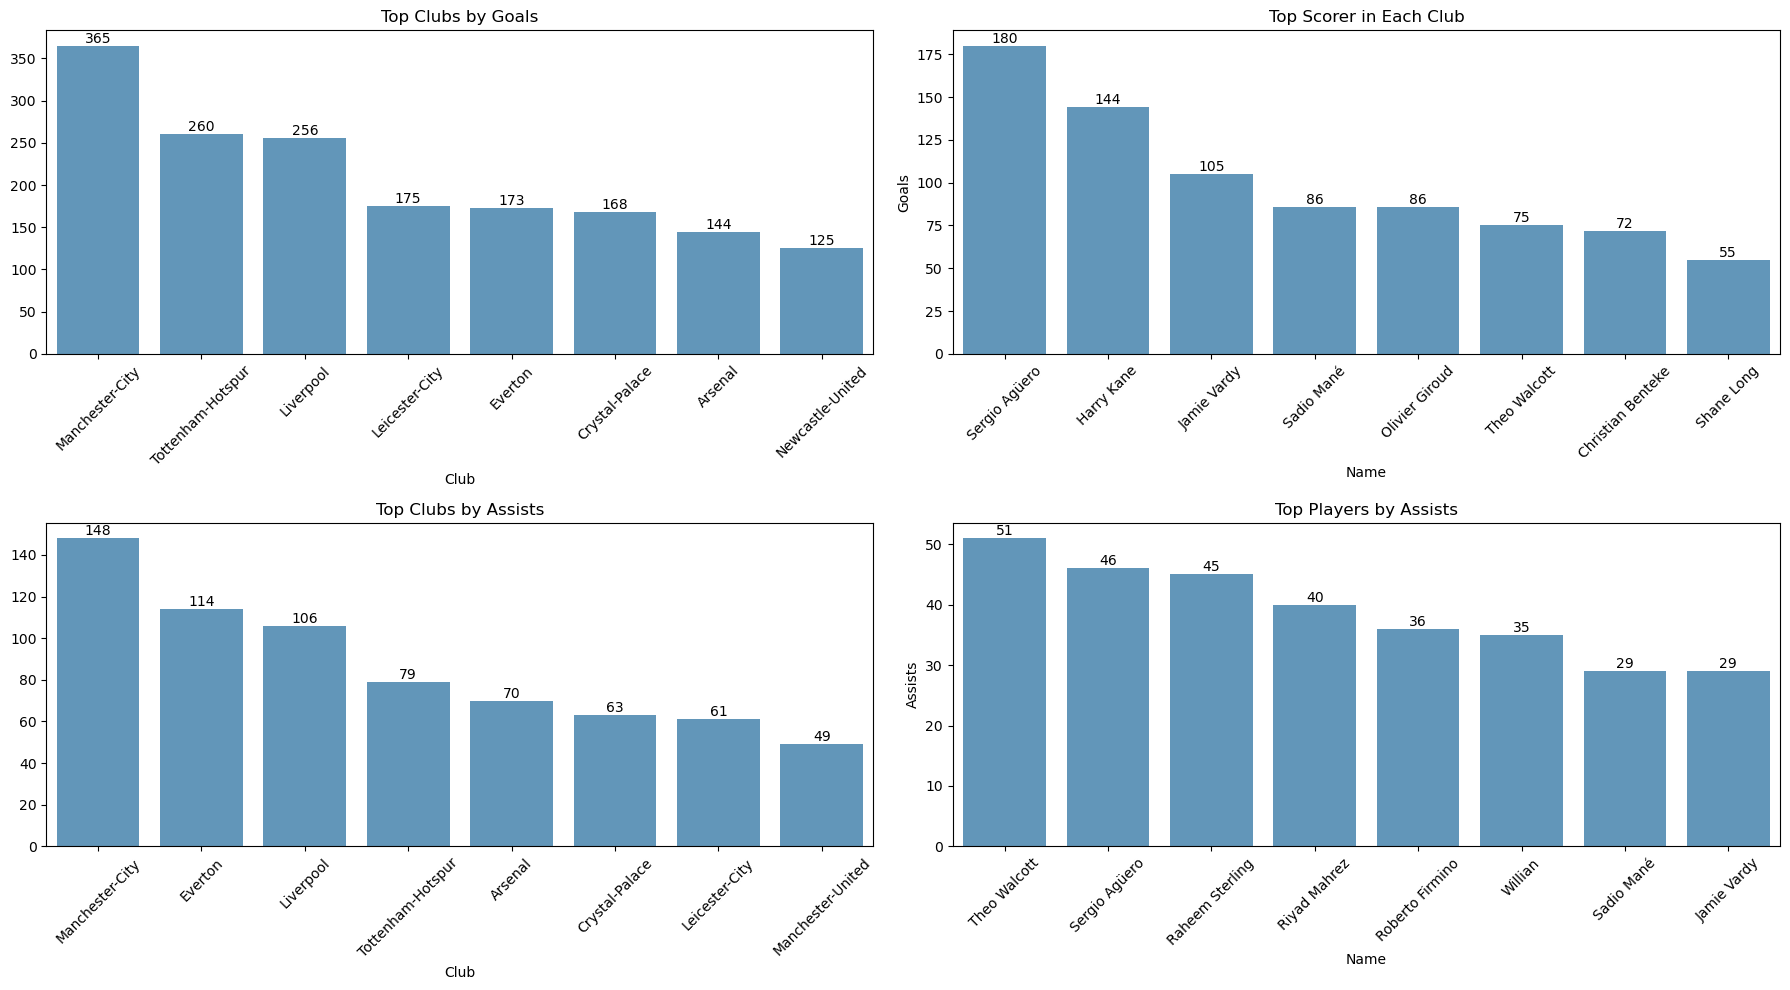

In [53]:
#bar plots for the top 8 clubs by goals, top scorer in each club, top 8 clubs by assists and top 8 players by assists
#the grouping 
club_goals = forwards.groupby('Club')['Goals'].sum().sort_values(ascending=False).head(8)
top_scorer_per_club = forwards.loc[forwards.groupby('Club')['Goals'].idxmax()][['Club', 'Name', 'Goals']]
top_scorer_per_club = top_scorer_per_club.sort_values(by='Goals', ascending=False).head(8)
club_assists = forwards.groupby('Club')['Assists'].sum().sort_values(ascending=False).head(8)
top_assist_players = forwards.sort_values(by='Assists', ascending=False).head(8)

plt.figure(figsize=(18, 10))

# plot 1
plt.subplot(2, 2, 1)
ax1 = sns.barplot(x=club_goals.index, y=club_goals.values, color='#5499C7')
plt.title('Top Clubs by Goals')
plt.xticks(rotation=45)# Rotate x-axis labels for better readability
# Adding data labels on top of the bars
for i, v in enumerate(club_goals.values):
    ax1.text(i, v, str(v), ha='center', va='bottom')

# plot 2
plt.subplot(2, 2, 2)
ax2 = sns.barplot(x=top_scorer_per_club['Name'], y=top_scorer_per_club['Goals'], color='#5499C7')
plt.title('Top Scorer in Each Club')
plt.xticks(rotation=45)# Rotate x-axis labels for better readability
# Adding data labels on top of the bars
for i, v in enumerate(top_scorer_per_club['Goals']):
    ax2.text(i, v, str(v), ha='center', va='bottom')

#plot 3 
plt.subplot(2, 2, 3)
ax3 = sns.barplot(x=club_assists.index, y=club_assists.values, color='#5499C7')
plt.title('Top Clubs by Assists')
plt.xticks(rotation=45)# Rotate x-axis labels for better readability
# Adding data labels on top of the bars
for i, v in enumerate(club_assists.values):
    ax3.text(i, v, str(v), ha='center', va='bottom')

#plot 4   
plt.subplot(2, 2, 4)
ax4 = sns.barplot(x=top_assist_players['Name'], y=top_assist_players['Assists'], color='#5499C7')
plt.title('Top Players by Assists')
plt.xticks(rotation=45)# Rotate x-axis labels for better readability
# Adding data labels on top of the bars
for i, v in enumerate(top_assist_players['Assists']):
    ax4.text(i, v, str(v), ha='center', va='bottom')
# Adjust layout 
plt.tight_layout()
#plt.savefig('club_assists.png', dpi=300, bbox_inches='tight')  # Save the figure before showing it
plt.show()


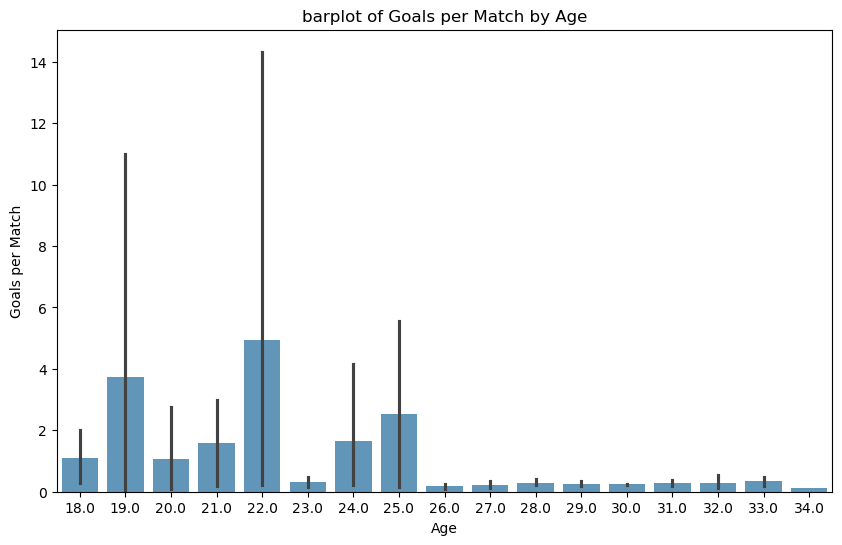

In [54]:
#goal per match distribution by aga
plt.figure(figsize=(10, 6))
sns.barplot(x='Age', y='Goals per match', data=forwards, color='#5499C7')
plt.title('barplot of Goals per Match by Age')
plt.xlabel('Age')
plt.ylabel('Goals per Match')

#plt.savefig('goals_per_match_by_age.png')
plt.show()  

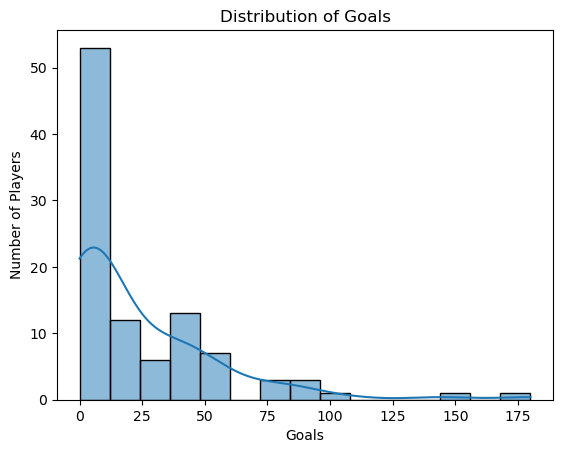

In [55]:
#goal distribution

sns.histplot(forwards['Goals'], bins=15, kde=True)
plt.title('Distribution of Goals')
plt.xlabel('Goals')
plt.ylabel('Number of Players')

#plt.savefig('goals_distribution.png')
plt.show()

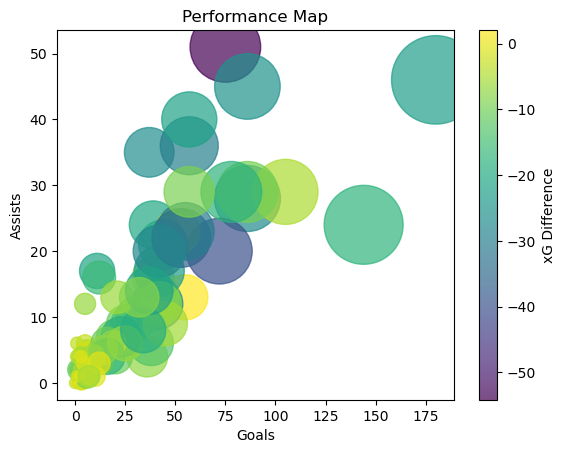

In [56]:
#4-Performance map 
plt.figure()

scatter = plt.scatter(
    forwards['Goals'],
    forwards['Assists'],
    c=forwards['xG_diff'],  
    s=forwards['xG_estimated'] * 20,
    alpha=0.7
)

plt.colorbar(scatter, label='xG Difference')

plt.xlabel('Goals')
plt.ylabel('Assists')
plt.title('Performance Map')
#plt.savefig('performance_map.png')

plt.show()

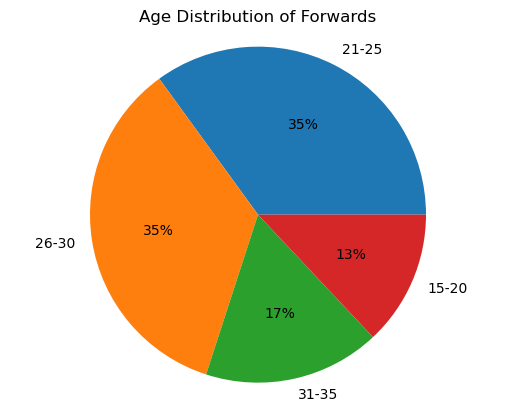

In [57]:
#pie chart for age (precntage of players in each age group) 
plt.figure()

plt.pie(
    forwards['Age Group'].value_counts(),
    labels=forwards['Age Group'].value_counts().index,
    autopct='%1.0f%%',   
)

plt.title('Age Distribution of Forwards')
plt.axis('equal') 

#plt.savefig('age_distribution_forwards.png')
plt.show()

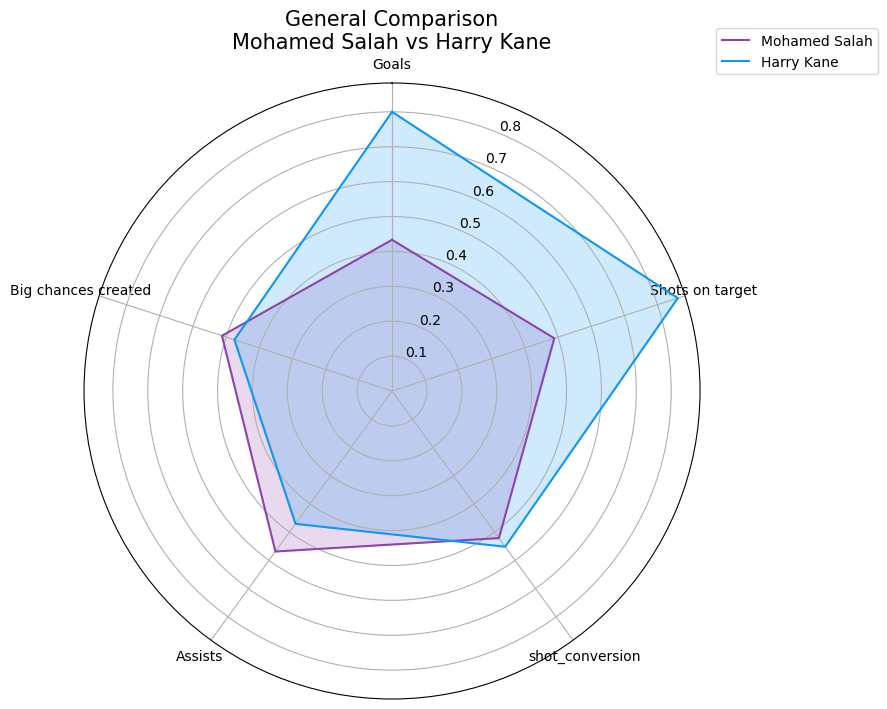

In [58]:
#comparison between the top 2 forwards  using radar chart for the following metrics: Goals, Shots on target,shot_conversion, Assists, Big chances created

forward_metrics = ['Goals', 'Shots on target', 'shot_conversion', 'Assists', 'Big chances created']
make_radar('Mohamed Salah', 'Harry Kane', forward_metrics, forwards)

#plt.savefig('Radar_Chart.png')

In [59]:
#data cleaning for midfielders
#filtering midfielders with at least 1 appearance
midfielders = df_analysis[df_analysis['Position'].str.contains('Midfielder')&(df_analysis['Appearances'] > 0)]
# Drop the specified columns from the midfielders DataFrame
cols_to_drop_midfielder = [
    'Clean sheets','Goals conceded','Tackles','Tackle success %','Last man tackles',
    'Blocked shots','Interceptions','Clearances','Headed Clearance','Clearances off line',
    'Recoveries','Duels won','Duels lost','Successful 50/50s','Aerial battles won','Aerial battles lost',
    'Own goals','Errors leading to goal','Saves','Penalties saved','Punches','High Claims','Catches',
    'Sweeper clearances','Throw outs','Goal Kicks'
]

midfielders = midfielders.drop(columns=cols_to_drop_midfielder)
midfielders.describe()

#feature engineering for midfielders
midfielders['passes_per_match'] = midfielders['Passes'] / midfielders['Appearances']
midfielders['assists_per_match'] = midfielders['Assists'] / midfielders['Appearances']
midfielders['big_chances_created_per_match'] = midfielders['Big chances created'] / midfielders['Appearances']
midfielders['shots_per_match'] = midfielders['Shots'] / midfielders['Appearances']

midfielders['shot_conversion'] = np.where(
    midfielders['Shots'] > 0,
    midfielders['Goals'] / midfielders['Shots'],
    np.nan
)

midfielders['goals_per_shot_on_target'] = np.where(
    midfielders['Shots on target'] > 0,
    midfielders['Goals'] / midfielders['Shots on target'],
    np.nan
)
midfielders.describe()


,Jersey Number,Age,Appearances,Wins,Losses,Goals,Goals per match,Headed goals,Goals with right foot,Goals with left foot,...,Yellow cards,Red cards,Fouls,Offsides,passes_per_match,assists_per_match,big_chances_created_per_match,shots_per_match,shot_conversion,goals_per_shot_on_target
count,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,...,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,163.000000,152.000000
mean,18.000000,25.982955,80.431818,33.414773,28.267045,7.414773,3.779318,0.619318,4.357955,2.352273,...,10.698864,0.357955,70.954545,7.125000,32.096434,0.082843,0.105720,0.912673,0.088720,0.259421
std,11.243792,3.754577,85.950789,40.551535,30.088104,11.057440,9.764815,1.342693,7.630184,5.047296,...,13.363712,0.822709,85.076961,13.344073,16.429493,0.094211,0.119365,0.584100,0.141063,0.209156
min,3.000000,17.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.333333,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9.500000,23.000000,19.000000,6.000000,7.000000,0.000000,0.050000,0.000000,0.000000,0.000000,...,1.000000,0.000000,11.500000,0.000000,20.831897,0.012712,0.018230,0.517410,0.026486,0.165000
50%,16.500000,26.000000,46.500000,18.500000,18.000000,3.000000,0.120000,0.000000,1.000000,1.000000,...,6.000000,0.000000,38.500000,2.000000,29.509023,0.062500,0.079002,0.861992,0.065672,0.233589
75%,23.000000,29.000000,121.250000,46.000000,39.500000,9.250000,1.000000,1.000000,5.250000,2.000000,...,15.000000,0.000000,98.750000,7.250000,43.505765,0.113306,0.156661,1.237959,0.101915,0.333333
max,69.000000,35.000000,539.000000,272.000000,158.000000,61.000000,57.000000,9.000000,45.000000,42.000000,...,81.000000,5.000000,438.000000,102.000000,82.000000,0.500000,1.000000,3.133333,1.000000,1.000000


In [60]:
midfielders_metrics = {
    "Top Goals": ("Goals", "top"),
    "Top Assists": ("Assists", "top"),
    "Top Passes": ("Passes", "top"),
    "Top Big Chances Created": ("Big chances created", "top"),
    "Top Passes per Match": ("Passes per match", "top"),
    "Top Cross Accuracy": ("Cross accuracy %", "top"),
    "Top Through Balls": ("Through balls", "top"),
    "Top Accurate Long Balls": ("Accurate long balls", "top"),
}

analyze_best_players(midfielders, midfielders_metrics, "MIDFIELDERS")


=== MIDFIELDERS ===

Top Goals: [('Gylfi Sigurdsson', 61)]
Top Assists: [('James Milner', 84)]
Top Passes: [('Jordan Henderson', 17932)]
Top Big Chances Created: [('Kevin De Bruyne', 97.0)]
Top Passes per Match: [('Thiago', 82.0)]
Top Cross Accuracy: [('Eberechi Eze', 67.0), ('Nampalys Mendy', 67.0)]
Top Through Balls: [('Jack Wilshere', 156.0)]
Top Accurate Long Balls: [('Mark Noble', 1484.0)]


/tmp/ipykernel_12400/2164916542.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_passers, x='Passes', y='Name', palette='viridis')


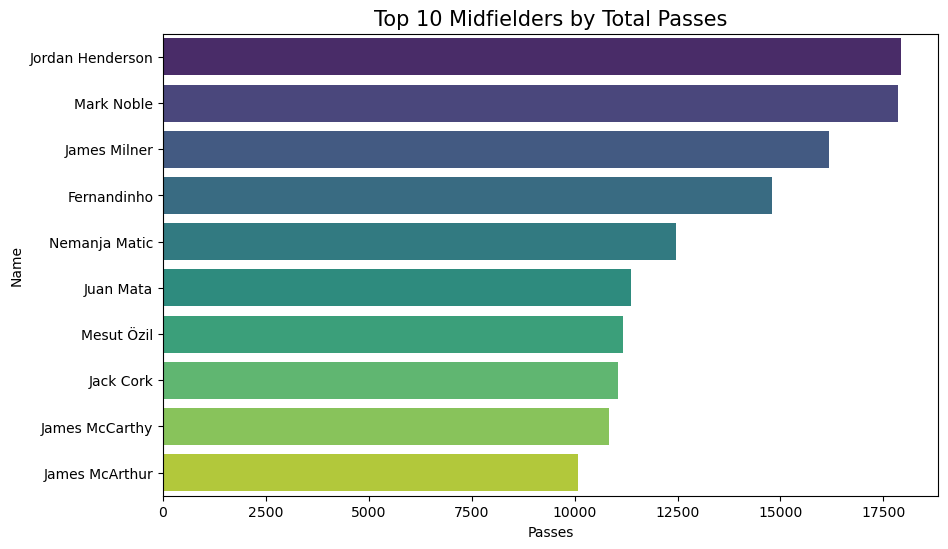

In [61]:
# 1. Bar Chart: Top 10 Passers
plt.figure(figsize=(10, 6))
top_passers = midfielders.nlargest(10, 'Passes')
sns.barplot(data=top_passers, x='Passes', y='Name', palette='viridis')
plt.title('Top 10 Midfielders by Total Passes', fontsize=15)
#plt.savefig('top_passers.png')
plt.show()

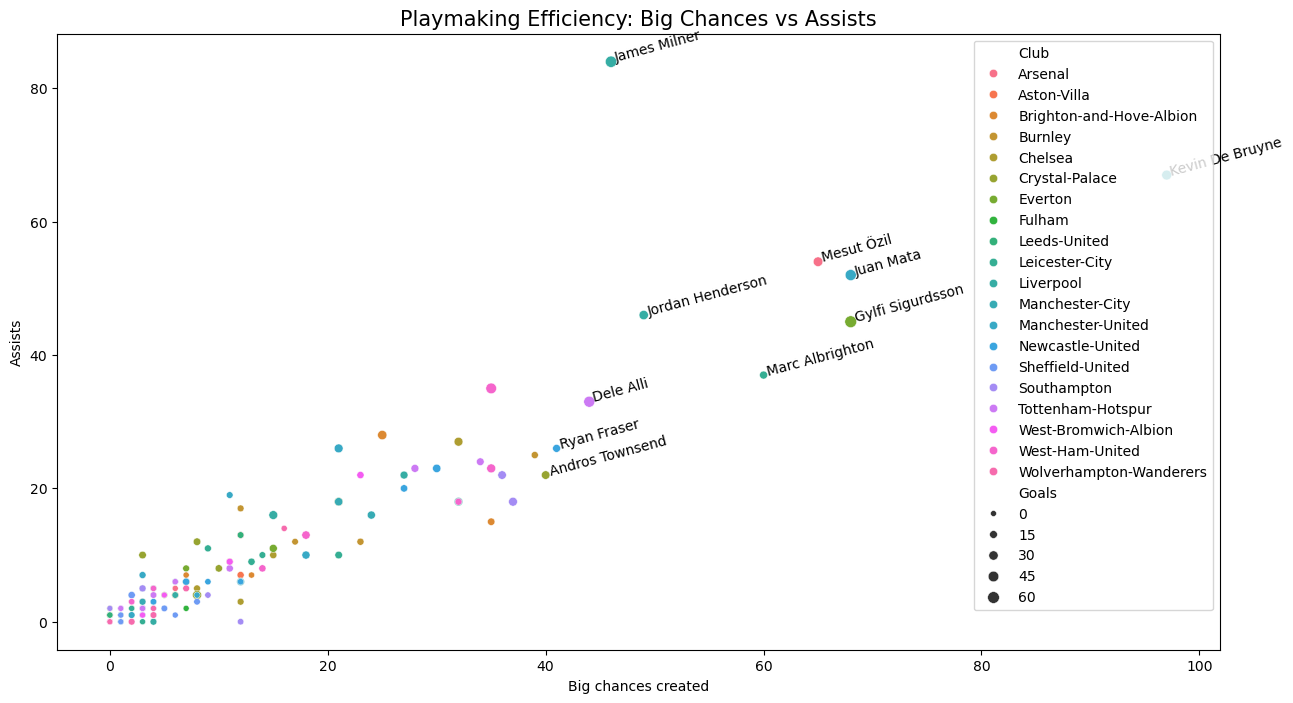

In [62]:
# 2. Scatter Plot: Big Chances Created vs Assists 
plt.figure(figsize=(15, 8))
scatter = sns.scatterplot(data=midfielders, x='Big chances created', y='Assists', hue='Club', size='Goals')

# add player names for the top 10 creators to avoid overcrowding
top_creators = midfielders.nlargest(10, 'Big chances created')
for i in range(len(top_creators)):
    plt.text(top_creators.iloc[i]['Big chances created']+0.2, 
             top_creators.iloc[i]['Assists'], 
             top_creators.iloc[i]['Name'], fontsize=10,rotation=15)

plt.title('Playmaking Efficiency: Big Chances vs Assists', fontsize=15)
#plt.savefig('playmaking_efficiency.png')
plt.show()

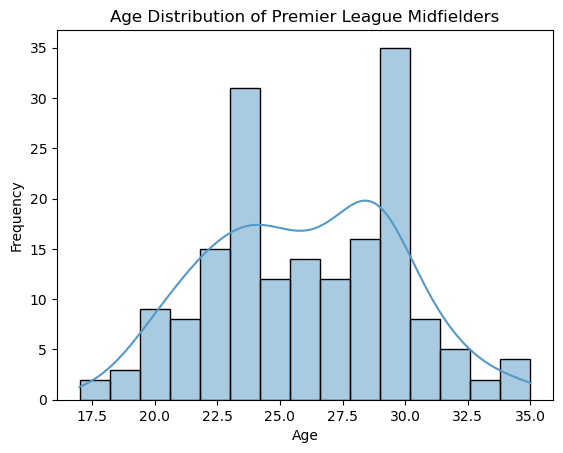

In [63]:
# 3. Age Analysis: Histogram 
sns.histplot(midfielders['Age'], bins=15, kde=True, color='#5499C7')
plt.title('Age Distribution of Premier League Midfielders')
plt.xlabel('Age')
plt.ylabel('Frequency')

#plt.savefig('age_distribution_midfielders.png')
plt.show()

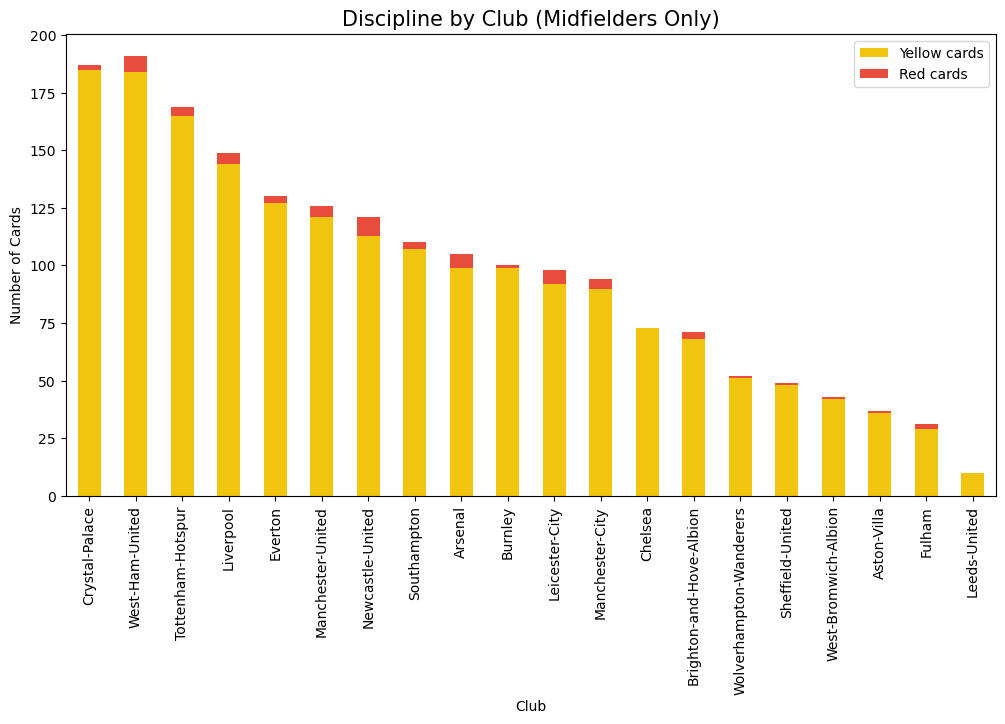

In [64]:
# 4. Discipline Analysis: Yellow vs Red Cards (Stacked Bar Chart)

club_discipline = midfielders.groupby('Club')[['Yellow cards', 'Red cards']].sum().sort_values(by='Yellow cards', ascending=False)
club_discipline.plot(kind='bar', stacked=True, figsize=(12, 6), color=['#f1c40f', '#e74c3c'])
plt.title('Discipline by Club (Midfielders Only)', fontsize=15)
plt.ylabel('Number of Cards')
#plt.savefig('club_discipline.png')
plt.show()

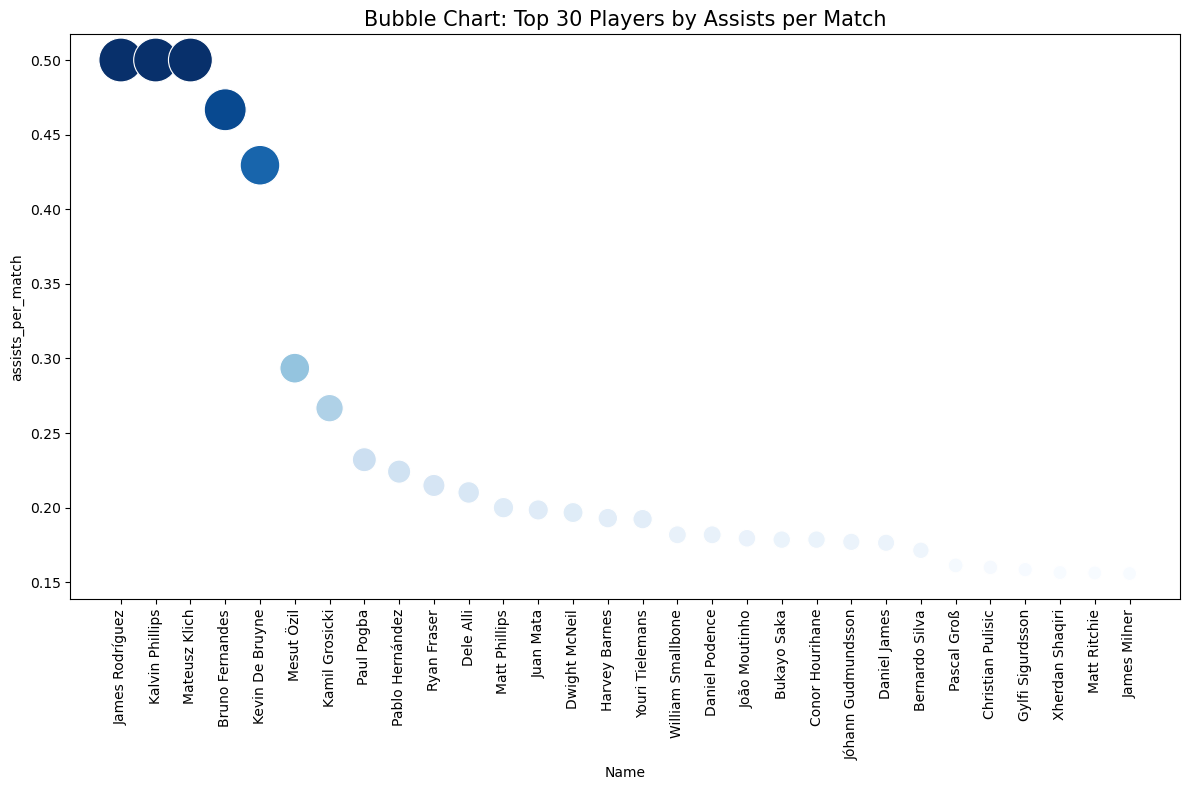

In [65]:
# 5. Bubble Chart: Assists per Match
# هنستخدم الـ Index كـ X-axis أو أي عمود تاني، ونخلي حجم الفقاعة يعبر عن الـ Assists per match
plt.figure(figsize=(12, 8))
# اخترنا أعلى 30 لاعب عشان الشكل يكون واضح
top_30_assists = midfielders.nlargest(30, 'assists_per_match')

sns.scatterplot(data=top_30_assists, x='Name', y='assists_per_match', 
                size='assists_per_match', sizes=(100, 1000), 
                hue='assists_per_match', palette='Blues', legend=None)

plt.xticks(rotation=90)
plt.title('Bubble Chart: Top 30 Players by Assists per Match', fontsize=15)
plt.tight_layout()
#plt.savefig('assists_per_match_bubble_chart.png')
plt.show()

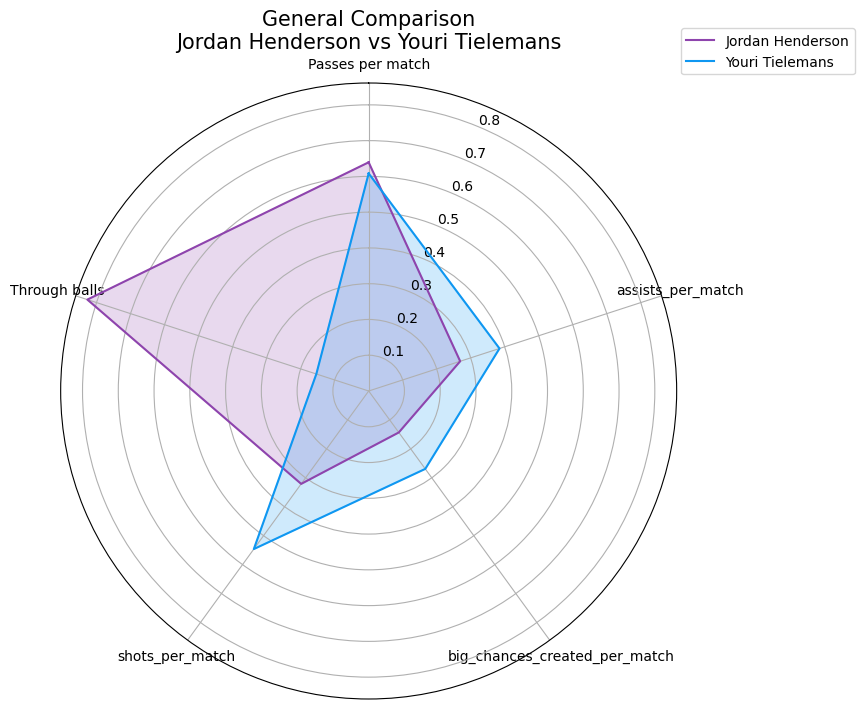

In [66]:
#comparison between the top 2 midfielders using radar chart for the following metrics: Passes per match, assists_per_match, big_chances_created_per_match, shots_per_match and through balls
mid_metrics_fair = [
    'Passes per match', 
    'assists_per_match', 
    'big_chances_created_per_match', 
    'shots_per_match',
    'Through balls'
]
make_radar('Jordan Henderson', 'Youri Tielemans', mid_metrics_fair, midfielders)


In [67]:
#data cleaning for defenders
#filtering defenders with at least 1 appearance
defenders = df_analysis[df_analysis['Position'].str.contains('Defender')&(df_analysis['Appearances'] > 0)]
# Drop the specified columns from the defenders DataFrame
cols_to_drop_defender = [
    'Goals','Goals per match','Headed goals','Goals with right foot','Goals with left foot',
    'Penalties scored','Freekicks scored','Shots','Shots on target','Shooting accuracy %',
    'Hit woodwork','Big chances missed','Assists','Passes','Passes per match',
    'Big chances created','Crosses','Cross accuracy %','Through balls','Accurate long balls'
]

defenders = defenders.drop(columns=cols_to_drop_defender)

#feature engineering 
defenders['tackle_success_rate'] = np.where(
    defenders['Tackles'] > 0,
    defenders['Tackle success %'] / 100,
    np.nan
)

defenders['aerial_duel_success'] = np.where(
    (defenders['Aerial battles won'] + defenders['Aerial battles lost']) > 0,
    defenders['Aerial battles won'] / (defenders['Aerial battles won'] + defenders['Aerial battles lost']),
    np.nan
)

defenders['clearances_per_match'] = defenders['Clearances'] / defenders['Appearances']
defenders['duel_success_rate'] = np.where(
    (defenders['Duels won'] + defenders['Duels lost']) > 0,
    defenders['Duels won'] / (defenders['Duels won'] + defenders['Duels lost']),
    np.nan
)

defenders['errors_per_match'] = defenders['Errors leading to goal'] / defenders['Appearances']
defenders['defensive_score'] = defenders['Interceptions'] + defenders['Tackles'] + defenders['Blocked shots']
defenders.describe()


,Jersey Number,Age,Appearances,Wins,Losses,Clean sheets,Goals conceded,Tackles,Tackle success %,Last man tackles,...,Yellow cards,Red cards,Fouls,Offsides,tackle_success_rate,aerial_duel_success,clearances_per_match,duel_success_rate,errors_per_match,defensive_score
count,156.000000,156.000000,156.000000,156.000000,156.00000,156.000000,156.000000,156.000000,156.000000,153.000000,...,156.000000,156.000000,156.000000,156.000000,152.000000,154.000000,156.000000,156.000000,156.000000,156.000000
mean,16.153846,26.525641,83.634615,35.647436,28.50641,21.121795,96.756410,142.653846,62.576923,1.588235,...,11.730769,0.416667,65.083333,3.737179,0.642237,0.560300,3.525111,0.576400,0.015530,277.756410
std,13.489855,4.064716,82.271783,38.640912,29.05734,23.602171,96.508758,154.891706,18.134991,3.221085,...,12.937241,0.744514,68.540919,5.220446,0.152029,0.144994,1.873310,0.092784,0.022942,295.456659
min,2.000000,18.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.010000,0.000000,0.000000,0.125000,0.000000,0.000000
25%,4.000000,23.000000,19.500000,7.000000,6.00000,2.750000,20.500000,31.500000,58.000000,0.000000,...,3.000000,0.000000,15.000000,0.000000,0.590000,0.502866,2.135638,0.536937,0.000000,56.750000
50%,15.000000,26.000000,56.000000,23.500000,19.00000,12.000000,59.500000,89.500000,66.000000,0.000000,...,7.000000,0.000000,40.500000,2.000000,0.660000,0.571429,3.137500,0.580178,0.009648,153.500000
75%,24.000000,30.000000,139.250000,50.500000,42.25000,31.000000,155.000000,204.500000,71.250000,2.000000,...,16.250000,1.000000,88.000000,5.000000,0.720000,0.625910,4.738281,0.623089,0.022859,438.750000
max,76.000000,38.000000,374.000000,183.000000,130.00000,107.000000,452.000000,728.000000,100.000000,24.000000,...,78.000000,3.000000,327.000000,29.000000,1.000000,1.000000,11.000000,1.000000,0.166667,1360.000000


In [68]:
#descriptive statistics for defenders
defenders_metrics = {
    "Top Tackles": ("Tackles", "top"),
    "Top Interceptions": ("Interceptions", "top"),
    "Top Clearances": ("Clearances", "top"),
    "Best Tackle Success": ("Tackle success %", "top"),
    "Best Aerial Duels": ("aerial_duel_success", "top"),
    "Fewest Errors": ("Errors leading to goal", "bottom"),
    "Top Defensive Score": ("defensive_score", "top"),
}

analyze_best_players(defenders, defenders_metrics, "DEFENDERS")


=== DEFENDERS ===

Top Tackles: [('Phil Bardsley', 728.0)]
Top Interceptions: [('Phil Jagielka', 618.0)]
Top Clearances: [('Phil Jagielka', 2974.0)]
Best Tackle Success: [('Ben White', 100.0), ('Liam Cooper', 100.0), ('Ethan Ampadu', 100.0), ('Jake Vokins', 100.0), ('Darnell Furlong', 100.0)]
Best Aerial Duels: [('Jimmy Dunne', 1.0), ('Kenny Tete', 1.0), ('Pascal Struijk', 1.0), ('Semi Ajayi', 1.0), ('Oskar Buur', 1.0)]
Fewest Errors: [('Kieran Tierney', 0.0), ('Rob Holding', 0.0), ('Gabriel Magalhães', 0.0), ('Neil Taylor', 0.0), ('Frédéric Guilbert', 0.0), ('Matthew Cash', 0.0), ('Ben White', 0.0), ('Tariq Lamptey', 0.0), ('Bernardo', 0.0), ('Dan Burn', 0.0), ('Jimmy Dunne', 0.0), ('Reece James', 0.0), ('César Azpilicueta', 0.0), ('Fikayo Tomori', 0.0), ('Emerson', 0.0), ('Tyrick Mitchell', 0.0), ('Lucas Digne', 0.0), ('Jarrad Branthwaite', 0.0), ('Jonjoe Kenny', 0.0), ('Michael Hector', 0.0), ('Denis Odoi', 0.0), ('Kenny Tete', 0.0), ('Ola Aina', 0.0), ('Luke Ayling', 0.0), ('Liam 

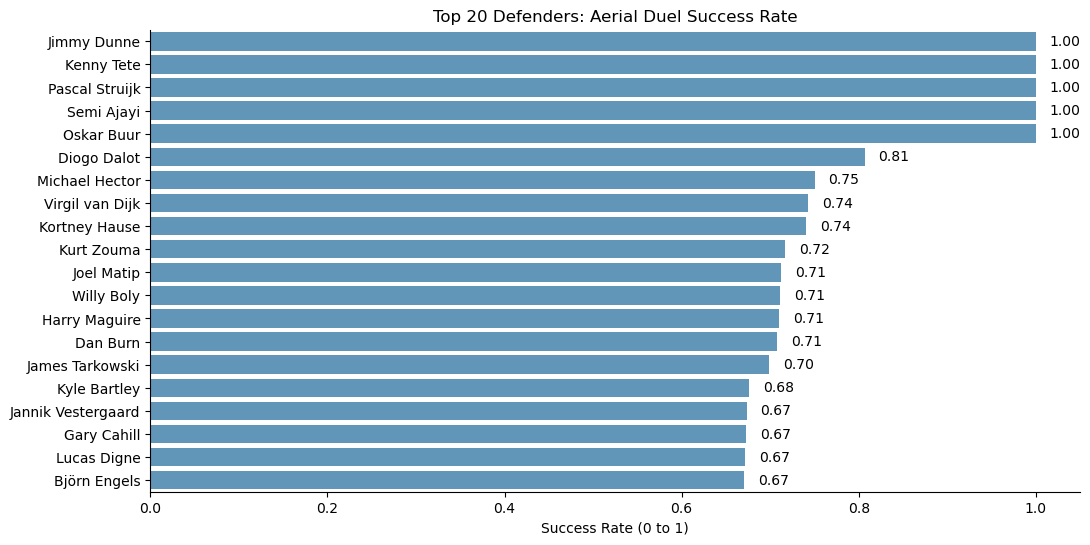

In [69]:
# 1: Top 20 Defenders in Aerial Duel Success
plt.figure(figsize=(12, 6))

#choosing the top 10 defenders based on aerial duel success rate
top_aerial = defenders.nlargest(20, 'aerial_duel_success')

ax = sns.barplot(data=top_aerial, x='aerial_duel_success', y='Name', color='#5499C7')

ax.set_title('Top 20 Defenders: Aerial Duel Success Rate')
ax.set_xlabel('Success Rate (0 to 1)')
ax.set_ylabel('')
ax.bar_label(ax.containers[0], fmt='%.2f', padding=10)

sns.despine()
#plt.savefig('top_aerial_duel_success.png')
plt.show()

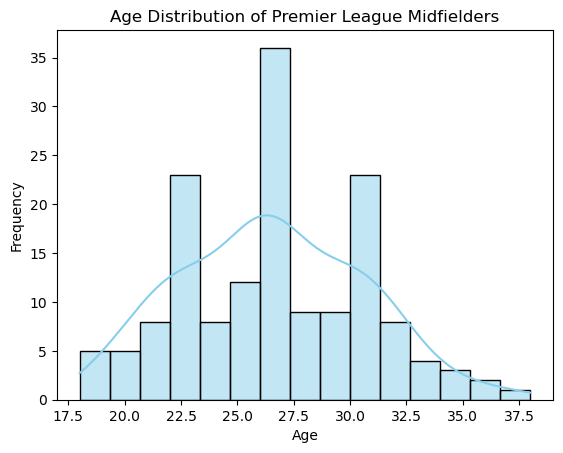

In [70]:
# 3. Age Analysis: Histogram 
sns.histplot(defenders['Age'], bins=15, kde=True, color='skyblue')
plt.title('Age Distribution of Premier League Midfielders')
plt.xlabel('Age')
plt.ylabel('Frequency')

#plt.savefig('age_distribution_defenders.png')
plt.show()

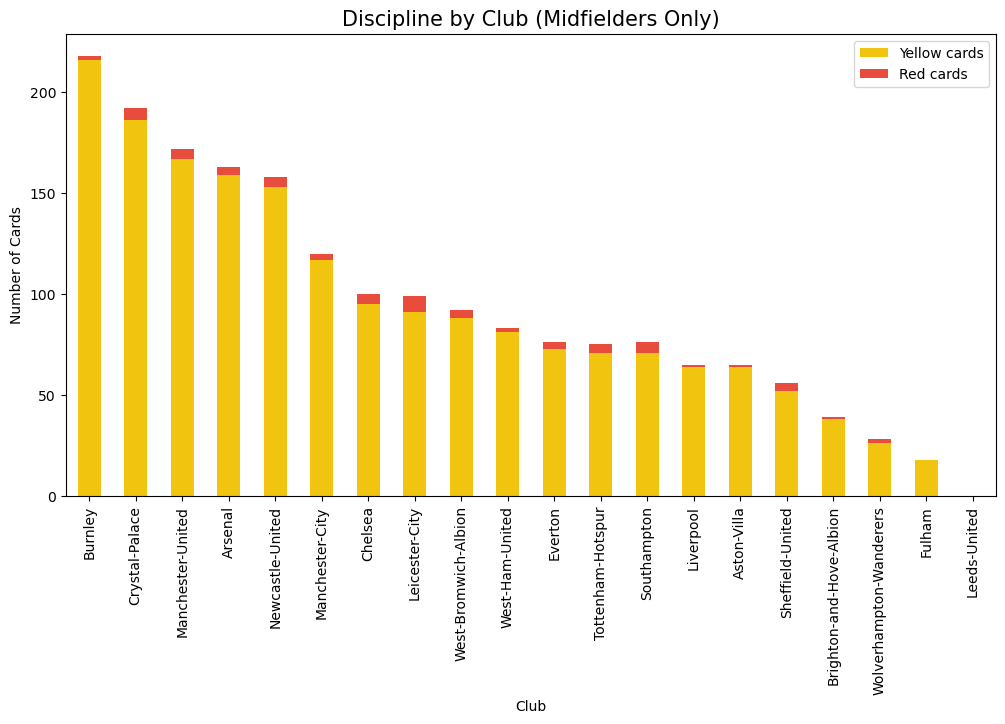

In [71]:
club_discipline = defenders.groupby('Club')[['Yellow cards', 'Red cards']].sum().sort_values(by='Yellow cards', ascending=False)
club_discipline.plot(kind='bar', stacked=True, figsize=(12, 6), color=['#f1c40f', '#e74c3c'])
plt.title('Discipline by Club (Midfielders Only)', fontsize=15)
plt.ylabel('Number of Cards')

#plt.savefig('club_discipline_defenders.png')
plt.show()

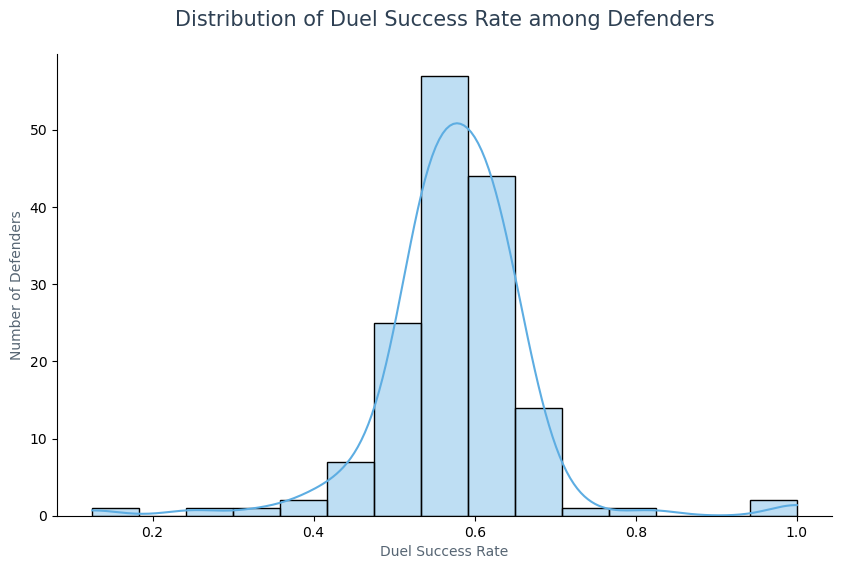

In [72]:
# Cell 4: Overall Duel Success Rate Distribution
plt.figure(figsize=(10, 6))

sns.histplot(defenders['duel_success_rate'].dropna(), bins=15, kde=True, color='#5DADE2', alpha=0.4)

plt.title('Distribution of Duel Success Rate among Defenders', fontsize=15, pad=20, color='#2E4053')
plt.xlabel('Duel Success Rate', color='#566573')
plt.ylabel('Number of Defenders', color='#566573')

sns.despine()

#plt.savefig('duel_success_rate_distribution.png')
plt.show()

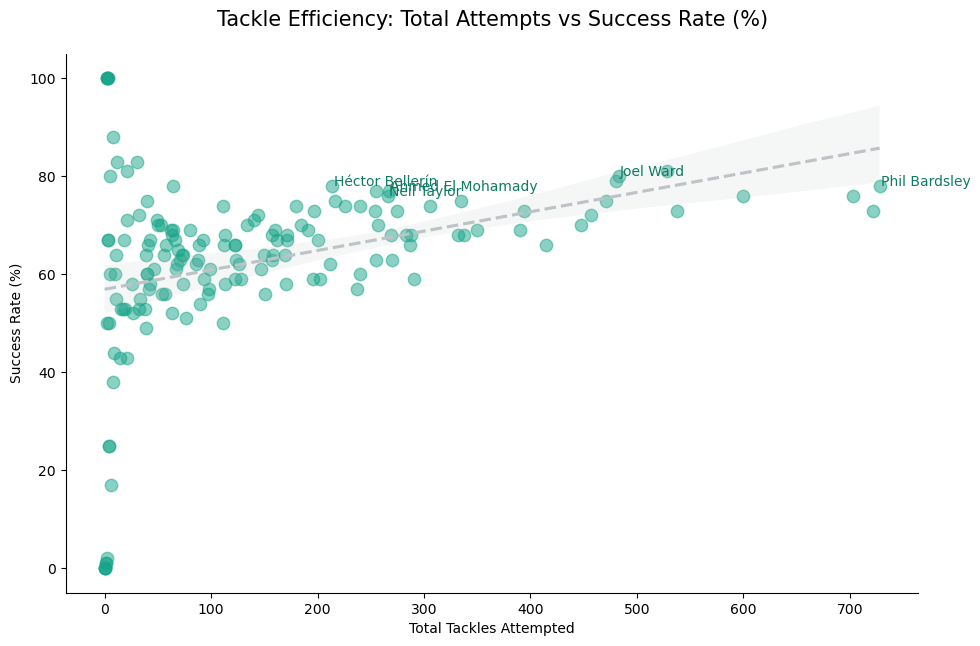

In [73]:
# Cell 5: Tackle Efficiency (Success vs Total Attempts)
plt.figure(figsize=(11, 7))


#relationship between total tackles and tackle success rate
ax = sns.regplot(data=defenders, x='Tackles', y='Tackle success %', scatter_kws={'s':80, 'alpha':0.5, 'color':'#17A589'}, line_kws={'color':'#BDC3C7', 'linestyle':'--'})

sharp_tacklers = defenders[(defenders['Tackle success %'] > 75) & 
                                       (defenders['Tackles'] > 30)].head(5)

for i, row in sharp_tacklers.iterrows():
    ax.text(row['Tackles'] + 1, row['Tackle success %'], row['Name'], 
            fontsize=10, color='#117A65')

ax.set_title('Tackle Efficiency: Total Attempts vs Success Rate (%)', fontsize=15, pad=20)
ax.set_xlabel('Total Tackles Attempted')
ax.set_ylabel('Success Rate (%)')

sns.despine()

#
#plt.savefig('tackle_efficiency.png')
plt.show()

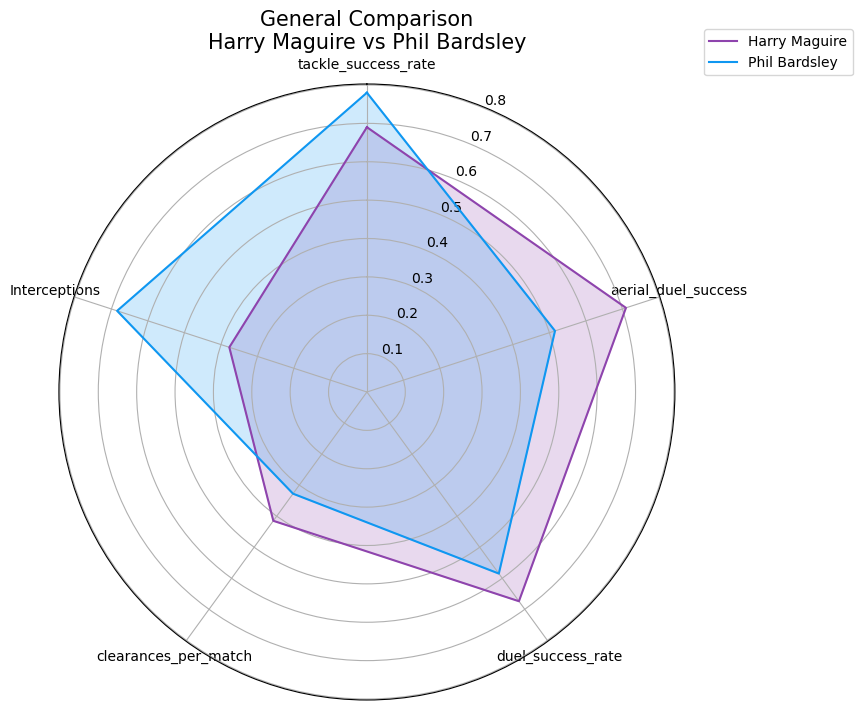

In [74]:
# Defensive Radar - Maguire vs Matip
def_metrics_fair = [
    'tackle_success_rate', 
    'aerial_duel_success', 
    'duel_success_rate',
    'clearances_per_match',
    'Interceptions'
]

make_radar('Harry Maguire', 'Phil Bardsley', def_metrics_fair, defenders)



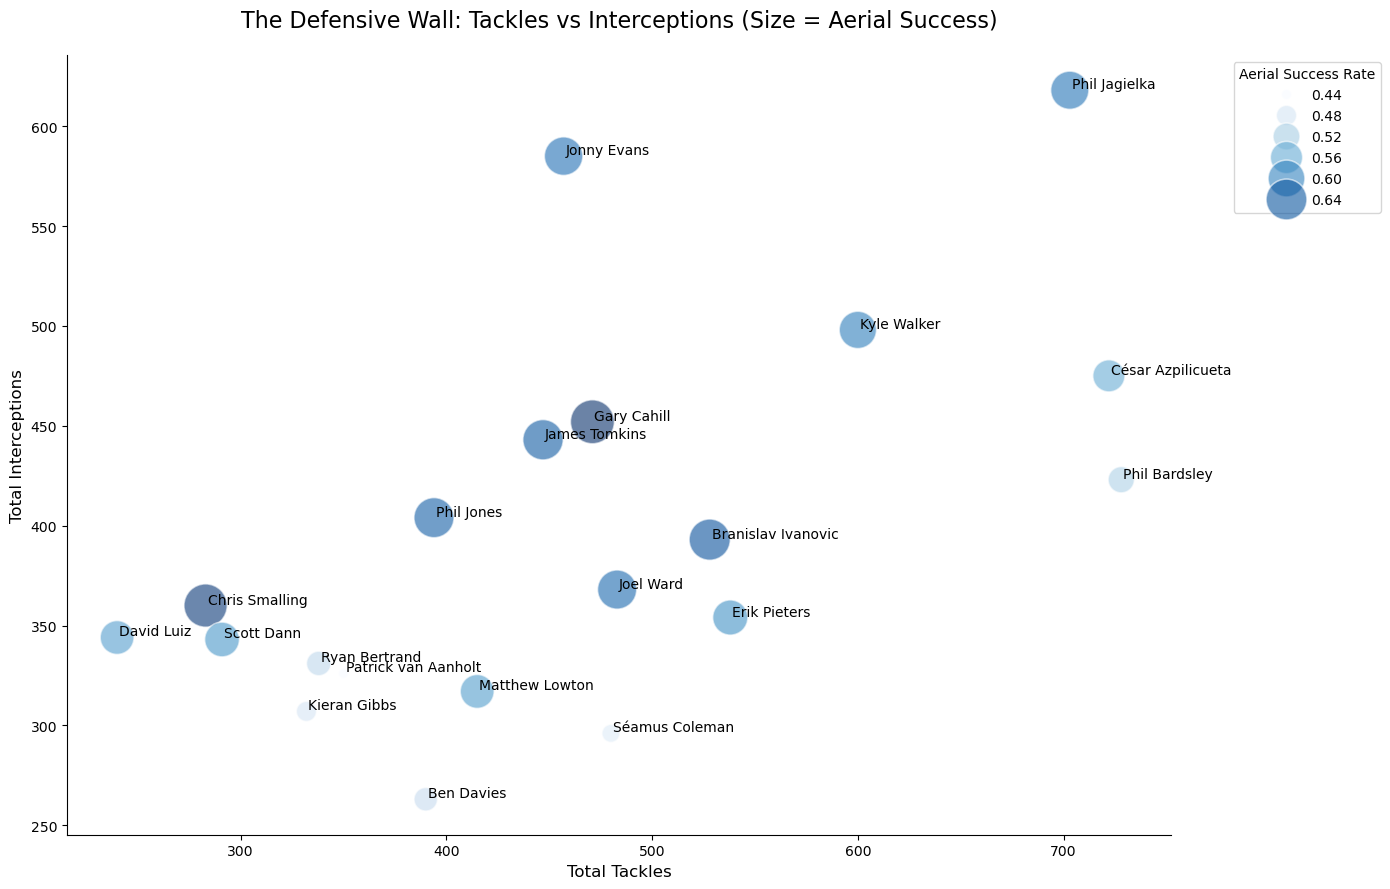

In [87]:
# Cell: The Ultimate Defender Bubble Chart
plt.figure(figsize=(14, 9))


sns.scatterplot(defenders.nlargest(20, 'defensive_score'), 
                x='Tackles', 
                y='Interceptions', 
                size='aerial_duel_success', 
                sizes=(50, 1000), 
                hue='aerial_duel_success',
                palette='Blues', 
                alpha=0.6, 
                edgecolor='white')

# إضافة أسماء أفضل 8 مدافعين (شاملين) عشان نفهم الرسمة
top_defenders = defenders.nlargest(20 ,'defensive_score')
for i, row in top_defenders.iterrows():
    plt.text(row['Tackles']+1, row['Interceptions']+1, row['Name'], fontsize=10)

# تجميل الرسمة
plt.title('The Defensive Wall: Tackles vs Interceptions (Size = Aerial Success)', fontsize=16, pad=20)
plt.xlabel('Total Tackles', fontsize=12)
plt.ylabel('Total Interceptions', fontsize=12)

# تحريك الـ Legend بره الرسمة عشان متغطيش على الفقاعات
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Aerial Success Rate')

sns.despine()
plt.tight_layout()

#plt.savefig('defensive_wall_bubble_chart.png')
plt.show()

In [ ]:
#data cleaning for goalkeepers
#filtering goalkeepers with at least 1 appearance
goalkeepers = df_analysis[df_analysis['Position'].str.contains('Goalkeeper')&(df_analysis['Appearances'] > 0)]
# Drop the specified columns from the goalkeepers DataFrame
cols_to_drop_goalkeeper = [
    'Goals','Goals per match','Headed goals','Goals with right foot','Goals with left foot',
    'Penalties scored','Freekicks scored','Shots','Shots on target','Shooting accuracy %',
    'Hit woodwork','Big chances missed','Assists','Passes','Passes per match',
    'Big chances created','Crosses','Cross accuracy %','Through balls','Accurate long balls',
    'Tackles','Tackle success %','Last man tackles','Blocked shots','Interceptions','Clearances',
    'Headed Clearance','Clearances off line','Recoveries','Duels won','Duels lost','Successful 50/50s',
    'Aerial battles won','Aerial battles lost','Own goals','Errors leading to goal','Offsides'
]

goalkeepers = goalkeepers.drop(columns=cols_to_drop_goalkeeper)


#feature engineering 
goalkeepers['save_percentage'] = np.where(
    (goalkeepers['Saves'] + goalkeepers['Goals conceded']) > 0,
    goalkeepers['Saves'] / (goalkeepers['Saves'] + goalkeepers['Goals conceded']),
    np.nan
)

goalkeepers['clean_sheets_per_match'] = goalkeepers['Clean sheets'] / goalkeepers['Appearances']
goalkeepers['goals_conceded_per_match'] = goalkeepers['Goals conceded'] / goalkeepers['Appearances']

goalkeepers['punches_high_claims_per_match'] = (goalkeepers['Punches'] + goalkeepers['High Claims']) / goalkeepers['Appearances']

goalkeepers['penalty_save_rate'] = np.where(
    goalkeepers['Penalties saved'] > 0,
    goalkeepers['Penalties saved'] / goalkeepers['Penalties saved'],  # لو عندك عدد penalties faced replace accordingly
    np.nan
)
goalkeepers['aerial_actions'] = goalkeepers['High Claims'] + goalkeepers['Punches']
goalkeepers.describe()

Index(['Name', 'Jersey Number', 'Club', 'Position', 'Nationality', 'Age',
       'Appearances', 'Wins', 'Losses', 'Clean sheets', 'Goals conceded',
       'Saves', 'Penalties saved', 'Punches', 'High Claims', 'Catches',
       'Sweeper clearances', 'Throw outs', 'Goal Kicks', 'Yellow cards',
       'Red cards', 'Fouls', 'save_percentage', 'clean_sheets_per_match',
       'goals_conceded_per_match', 'punches_high_claims_per_match',
       'penalty_save_rate', 'aerial_actions'],
      dtype='object')

In [77]:
goalkeepers_metrics = {
    "Most Saves": ("Saves", "top"),
    "Best Save %": ("save_percentage", "top"),
    "Most Clean Sheets": ("Clean sheets", "top"),
    "Best Penalty Save Rate": ("penalty_save_rate", "top"),
    "Fewest Goals Conceded": ("Goals conceded", "bottom"),
}

analyze_best_players(goalkeepers, goalkeepers_metrics, "GOALKEEPERS")


=== GOALKEEPERS ===

Most Saves: [('Joe Hart', 941.0)]
Best Save %: [('Sergio Romero', 0.9090909090909091)]
Most Clean Sheets: [('Joe Hart', 127.0)]
Best Penalty Save Rate: [('Bernd Leno', 1.0), ('Tom Heaton', 1.0), ('Emiliano Martínez', 1.0), ('Mat Ryan', 1.0), ('Nick Pope', 1.0), ('Kepa Arrizabalaga', 1.0), ('Willy Caballero', 1.0), ('Wayne Hennessey', 1.0), ('Jordan Pickford', 1.0), ('Jonas Lössl', 1.0), ('Kasper Schmeichel', 1.0), ('Eldin Jakupovic', 1.0), ('Loris Karius', 1.0), ('Alisson', 1.0), ('Adrián', 1.0), ('Ederson', 1.0), ('Scott Carson', 1.0), ('David de Gea', 1.0), ('Sergio Romero', 1.0), ('Dean Henderson', 1.0), ('Martin Dubravka', 1.0), ('Karl Darlow', 1.0), ('Aaron Ramsdale', 1.0), ('Alex McCarthy', 1.0), ('Angus Gunn', 1.0), ('Fraser Forster', 1.0), ('Hugo Lloris', 1.0), ('Paulo Gazzaniga', 1.0), ('Joe Hart', 1.0), ('Lukasz Fabianski', 1.0), ('Darren Randolph', 1.0), ('Rui Patrício', 1.0), ('John Ruddy', 1.0)]
Fewest Goals Conceded: [('Will Norris', 0.0)]


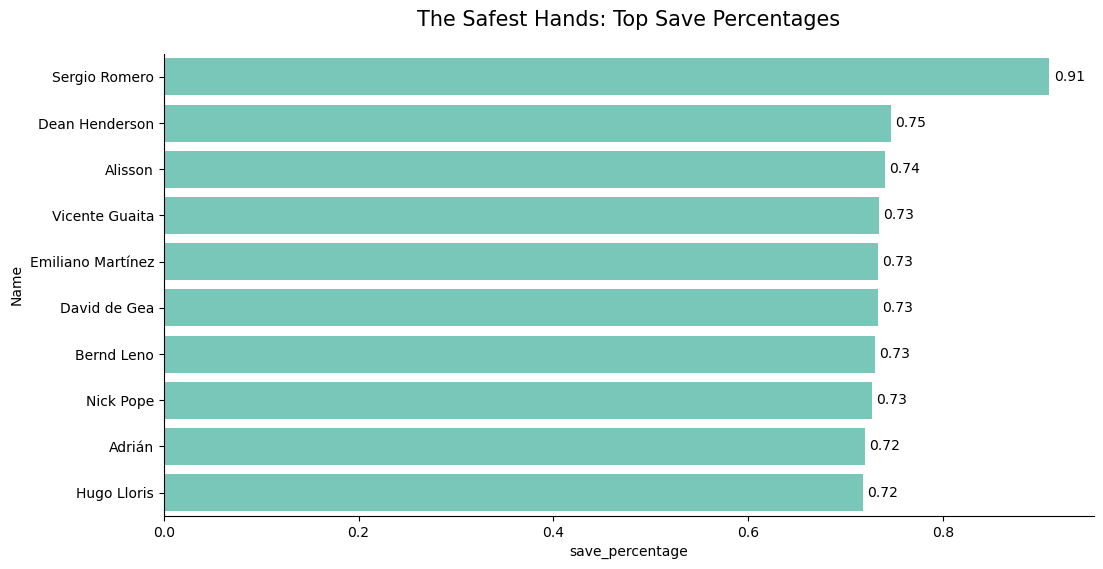

In [ ]:
#data visualization for goalkeepers
# Cell 1: Top 10 Goalkeepers by Save Percentage
plt.figure(figsize=(12, 6))
top_save_pct = goalkeepers[goalkeepers['Appearances'] > 5].nlargest(10, 'save_percentage')

ax = sns.barplot(data=top_save_pct, x='save_percentage', y='Name', color='#48C9B0', alpha=0.8)
ax.set_title('The Safest Hands: Top Save Percentages', fontsize=15, pad=20)
ax.bar_label(ax.containers[0], fmt='%.2f', padding=3)
sns.despine()
#plt.savefig('top_save_percentage.png')
plt.show()


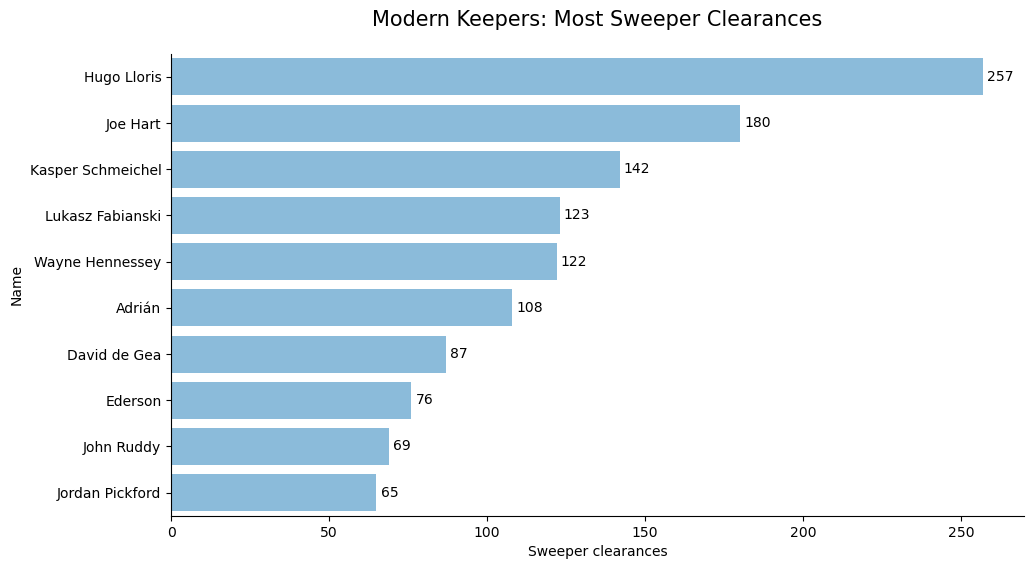

In [ ]:
# Cell 3: The Sweeper Keeper (Sweeper Clearances)
plt.figure(figsize=(11, 6))
top_sweepers = goalkeepers.nlargest(10, 'Sweeper clearances')

ax = sns.barplot(data=top_sweepers, x='Sweeper clearances', y='Name', color='#5DADE2', alpha=0.8)
ax.set_title('Modern Keepers: Most Sweeper Clearances', fontsize=15, pad=20)
ax.bar_label(ax.containers[0], padding=3)
sns.despine()
#plt.savefig('sweeper_clearances.png')
plt.show()

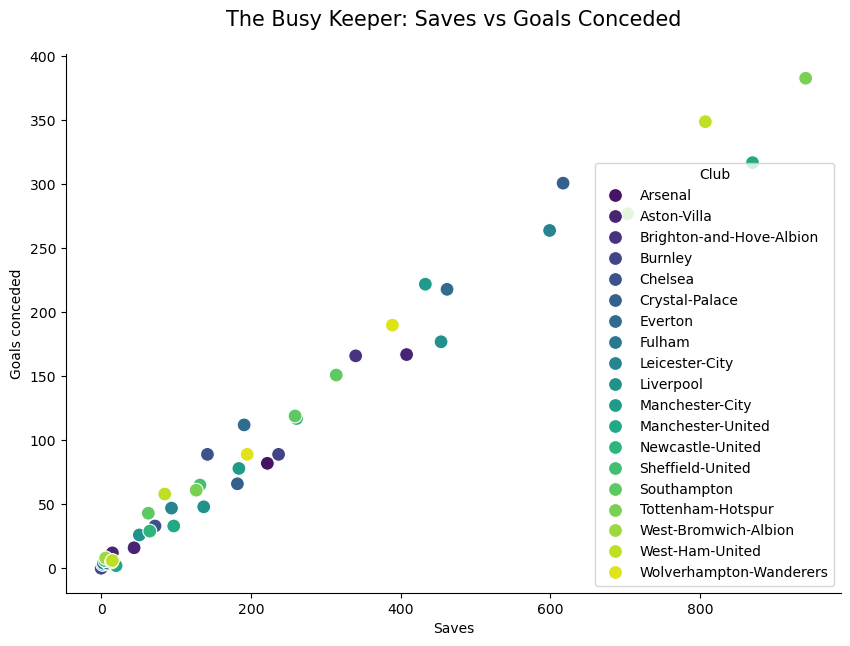

In [ ]:
# Cell 4: Saves vs Goals Conceded (The Busy Keeper)
plt.figure(figsize=(10, 7))
ax = sns.scatterplot(data=goalkeepers, x='Saves', y='Goals conceded', hue='Club', s=100, palette='viridis')
ax.set_title('The Busy Keeper: Saves vs Goals Conceded', fontsize=15, pad=20)
sns.despine()
#plt.savefig('busy_keeper.png')
plt.show()

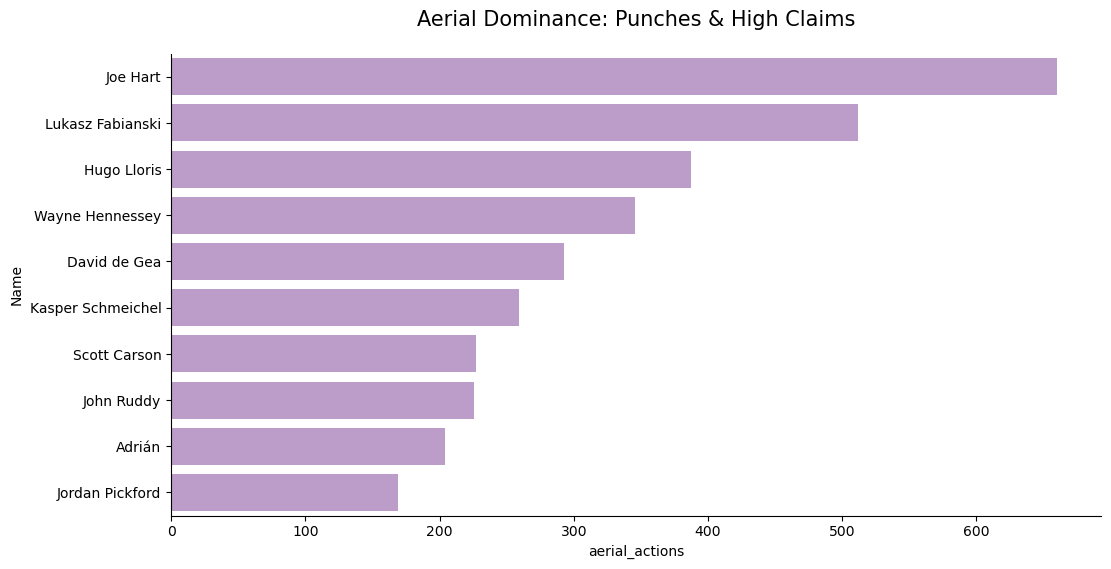

In [ ]:
# Cell 5: Aerial Dominance (High Claims + Punches)
plt.figure(figsize=(12, 6))

top_aerial = goalkeepers.nlargest(10, 'aerial_actions')

ax = sns.barplot(data=top_aerial, x='aerial_actions', y='Name', color='#AF7AC5', alpha=0.8)
ax.set_title('Aerial Dominance: Punches & High Claims', fontsize=15, pad=20)
sns.despine()
#plt.savefig('aerial_dominance.png')
plt.show()

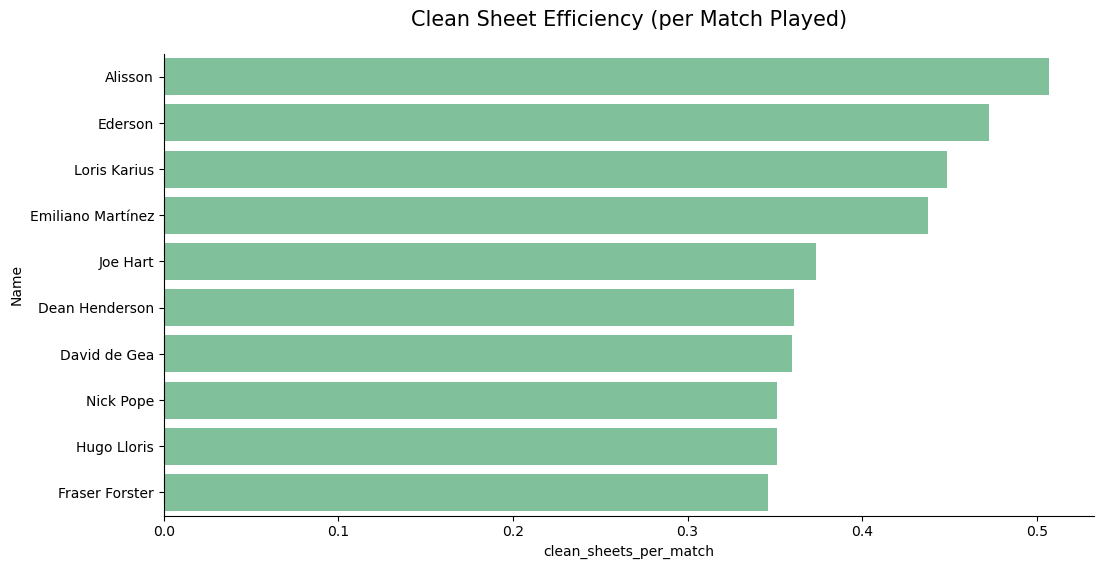

In [ ]:
# Cell 6: Clean Sheet Efficiency
plt.figure(figsize=(12, 6))
top_cs_rate = goalkeepers[goalkeepers['Appearances'] > 10].nlargest(10, 'clean_sheets_per_match')

ax = sns.barplot(data=top_cs_rate, x='clean_sheets_per_match', y='Name', color='#52BE80', alpha=0.8)
ax.set_title('Clean Sheet Efficiency (per Match Played)', fontsize=15, pad=20)
sns.despine()
#plt.savefig('clean_sheet_efficiency.png')
plt.show()

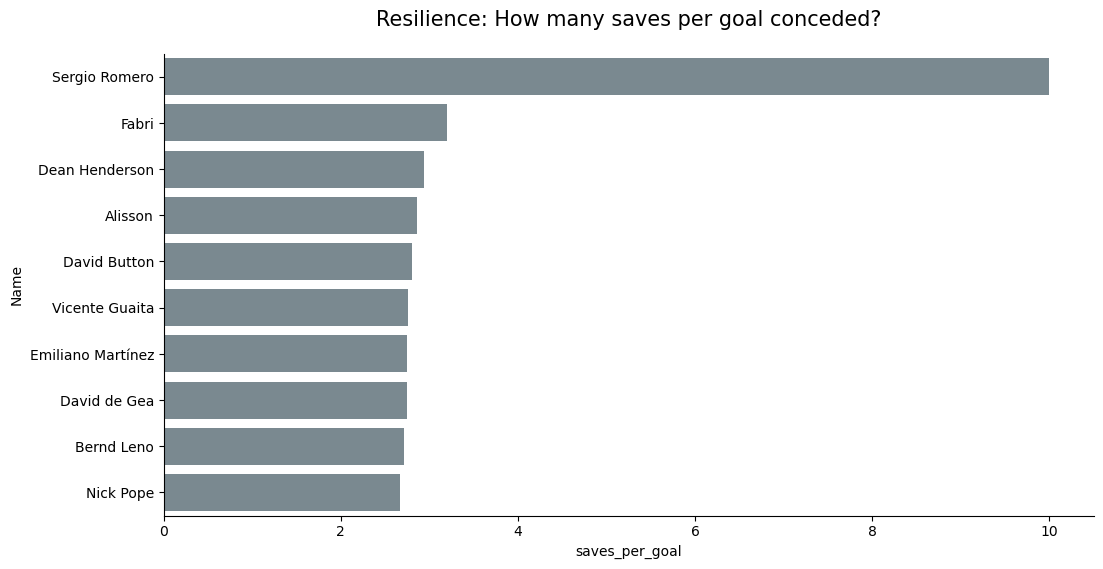

In [ ]:
# Cell 8: Saves per Goal Conceded
plt.figure(figsize=(12, 6))
goalkeepers['saves_per_goal'] = goalkeepers['Saves'] / goalkeepers['Goals conceded']
top_resilience = goalkeepers[goalkeepers['Goals conceded'] > 0].nlargest(10, 'saves_per_goal')

ax = sns.barplot(data=top_resilience, x='saves_per_goal', y='Name', color='#546E7A', alpha=0.8)
ax.set_title('Resilience: How many saves per goal conceded?', fontsize=15, pad=20)
sns.despine()
#plt.savefig('saves_per_goal_conceded.png')
plt.show()

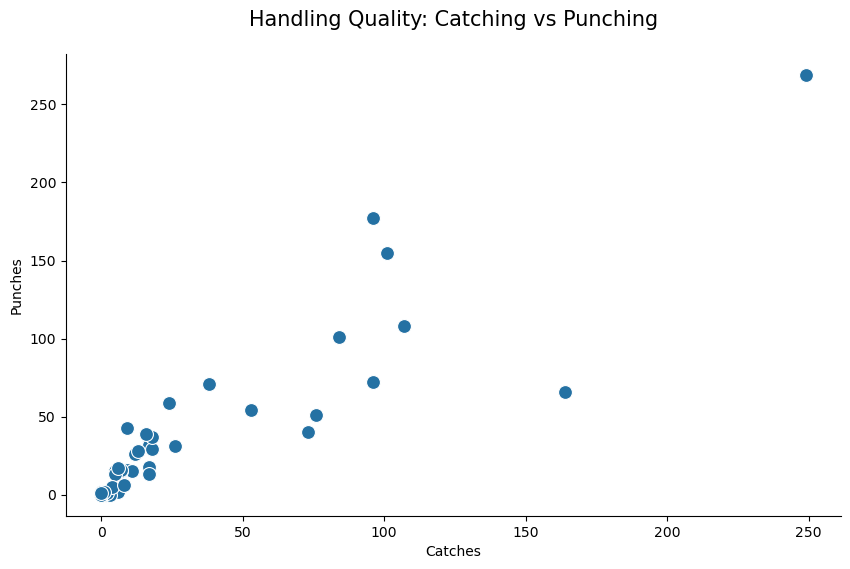

In [ ]:
# Cell 9: Handling Quality (Catches vs Punches)
plt.figure(figsize=(10, 6))
ax = sns.scatterplot(data=goalkeepers, x='Catches', y='Punches', color='#2471A3', s=100)
plt.title('Handling Quality: Catching vs Punching', fontsize=15, pad=20)
sns.despine()
#plt.savefig('handling_quality.png')
plt.show()

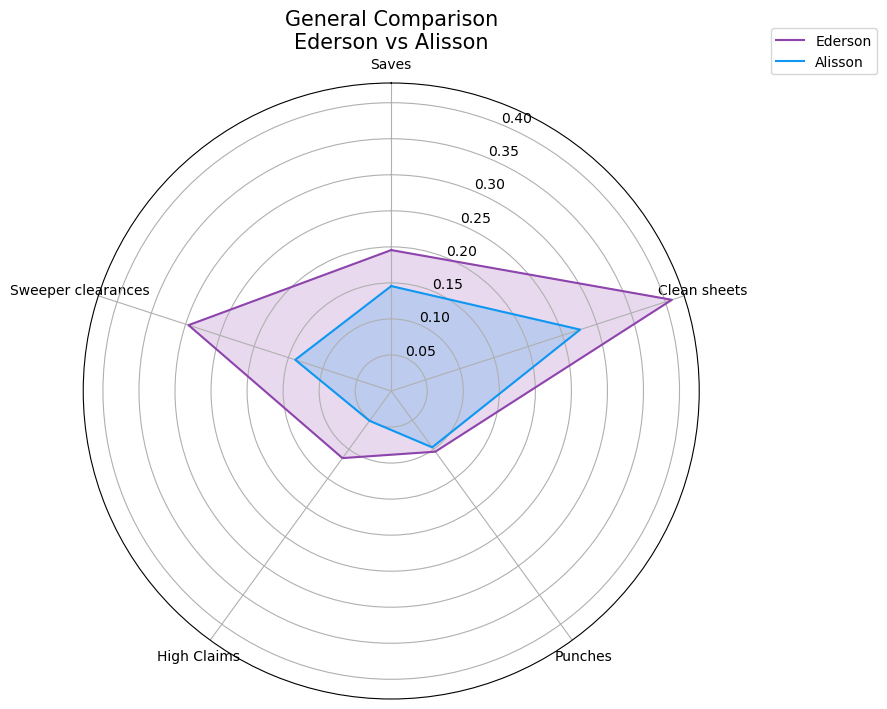

In [85]:
# Radar Chart for Comparing Two Keepers
import numpy as np

metrics_to_show = ['Saves', 'Clean sheets', 'Punches', 'High Claims', 'Sweeper clearances']
make_radar('Ederson', 'Alisson', metrics_to_show,goalkeepers)